# Dataset Demo - Satellite Lightning: MTG LI

This notebook demonstrates the use of [EUMETSAT's Meteosat Third Generation Lighning Imager (MTG LI)](https://user.eumetsat.int/resources/user-guides/mtg-li-level-2-data-guide) datset with PyEarthTools.

### EW4Energy Dataset info
* Duration: 6 months -  April to September 2025
* Temporal Resoltuion file per 15 minutes (20MB per file)
* Spatial Extent
  * Latitude 0N to 20N
  * Longitude 27W to 20E


In [1]:
!ls /gws/nopw/j04/ew4energy/MTG_LI/20250424 | grep 2025042417

flash_accumulation_20250424170000_15mins.nc
flash_accumulation_20250424171500_15mins.nc
flash_accumulation_20250424173000_15mins.nc
flash_accumulation_20250424174500_15mins.nc


In [2]:
import os
import pathlib

In [41]:
import numpy
import scipy
import scipy.interpolate

In [3]:
import matplotlib
import cartopy

In [4]:
import iris

In [5]:
import xarray

In [6]:
path1 = pathlib.Path('/gws/nopw/j04/ew4energy/MTG_LI/20250422/flash_accumulation_20250422094500_15mins.nc')

In [11]:
mtg_li_ds = xarray.open_dataset(path1)

In [12]:
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Dimensions without coordinates: y, x
Data variables:
    latitude            (y, x) float32 10MB ...
    longitude           (y, x) float32 10MB ...
    flash_accumulation  (y, x) float32 10MB ...
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [13]:
mtg_li_ds['flash_accumulation'].values.max()

np.float32(22.883001)

In [18]:
mtg_li_ds['longitude'][0,:20].data

array([-27.115114, -27.091827, -27.06855 , -27.045279, -27.022017,
       -26.99876 , -26.975513, -26.952274, -26.92904 , -26.905817,
       -26.8826  , -26.859392, -26.836191, -26.812998, -26.78981 ,
       -26.766632, -26.743462, -26.720299, -26.697144, -26.673994],
      dtype=float32)

In [19]:
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Coordinates:
    latitude            (y, x) float32 10MB ...
    longitude           (y, x) float32 10MB ...
Dimensions without coordinates: y, x
Data variables:
    flash_accumulation  (y, x) float32 10MB ...
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [20]:
mtg_li_ds = mtg_li_ds.set_coords(['latitude','longitude'])
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Coordinates:
    latitude            (y, x) float32 10MB ...
    longitude           (y, x) float32 10MB ...
Dimensions without coordinates: y, x
Data variables:
    flash_accumulation  (y, x) float32 10MB ...
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [21]:
mtg_li_ds

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Coordinates:
    latitude            (y, x) float32 10MB ...
    longitude           (y, x) float32 10MB ...
Dimensions without coordinates: y, x
Data variables:
    flash_accumulation  (y, x) float32 10MB ...
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

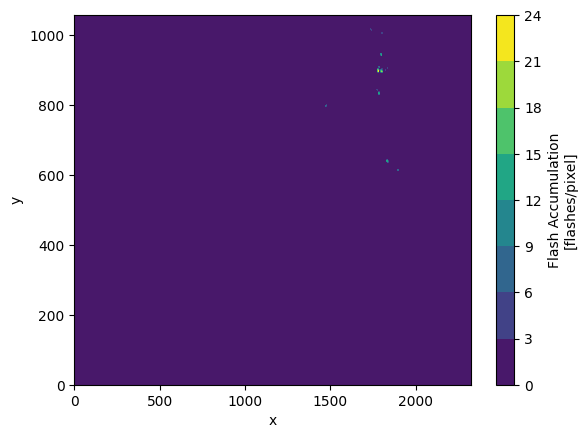

In [26]:
mtg_li_ds['flash_accumulation'].plot.contourf()

In [27]:
mtg_li_ds.set_coords(["latitude", "longitude"])

<xarray.Dataset> Size: 30MB
Dimensions:             (y: 1058, x: 2327)
Coordinates:
    latitude            (y, x) float32 10MB 20.19 20.19 ... 0.02742 0.02742
    longitude           (y, x) float32 10MB -27.12 -27.09 -27.07 ... 18.5 18.52
Dimensions without coordinates: y, x
Data variables:
    flash_accumulation  (y, x) float32 10MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    title:                Accumulated flash_accumulation from MTG Lightning I...
    institution:          NCAS Leeds
    source:               MTG Lightning Imager
    history:              Created 2025-10-03T15:12:02.989146Z
    time_coverage_start:  2025-04-22T09:30:29Z
    time_coverage_end:    2025-04-22T09:44:59Z

In [28]:
da = mtg_li_ds["flash_accumulation"]

lat2d = mtg_li_ds["latitude"].values
lon2d = mtg_li_ds["longitude"].values
values = da.values

In [32]:
# Define target regular grid
lat_out = numpy.arange(numpy.nanmin(lat2d), numpy.nanmax(lat2d), 0.05)
lon_out = numpy.arange(numpy.nanmin(lon2d), numpy.nanmax(lon2d), 0.05)


In [34]:
lon_grid, lat_grid = numpy.meshgrid(lon_out, lat_out)

In [36]:
# Flatten source points
points = numpy.column_stack([lon2d.ravel(), lat2d.ravel()])
data = values.ravel()

In [39]:
# Remove missing values
valid = numpy.isfinite(points[:, 0]) & numpy.isfinite(points[:, 1]) & numpy.isfinite(data)


In [43]:
regridded = scipy.interpolate.griddata(
    points[valid],
    data[valid],
    (lon_grid, lat_grid),
    method="linear",   # or "nearest"
)

In [46]:
mtg_li_ds_clean = xarray.Dataset(
    data_vars={
        "flash_accumulation": (("latitude", "longitude"), regridded)
    },
    coords={
        "latitude": lat_out,
        "longitude": lon_out,
    },
)

In [47]:
mtg_li_ds_clean

<xarray.Dataset> Size: 3MB
Dimensions:             (latitude: 404, longitude: 942)
Coordinates:
  * latitude            (latitude) float64 3kB 0.02713 0.07713 ... 20.13 20.18
  * longitude           (longitude) float64 8kB -27.12 -27.07 ... 19.88 19.93
Data variables:
    flash_accumulation  (latitude, longitude) float64 3MB nan nan ... nan nan

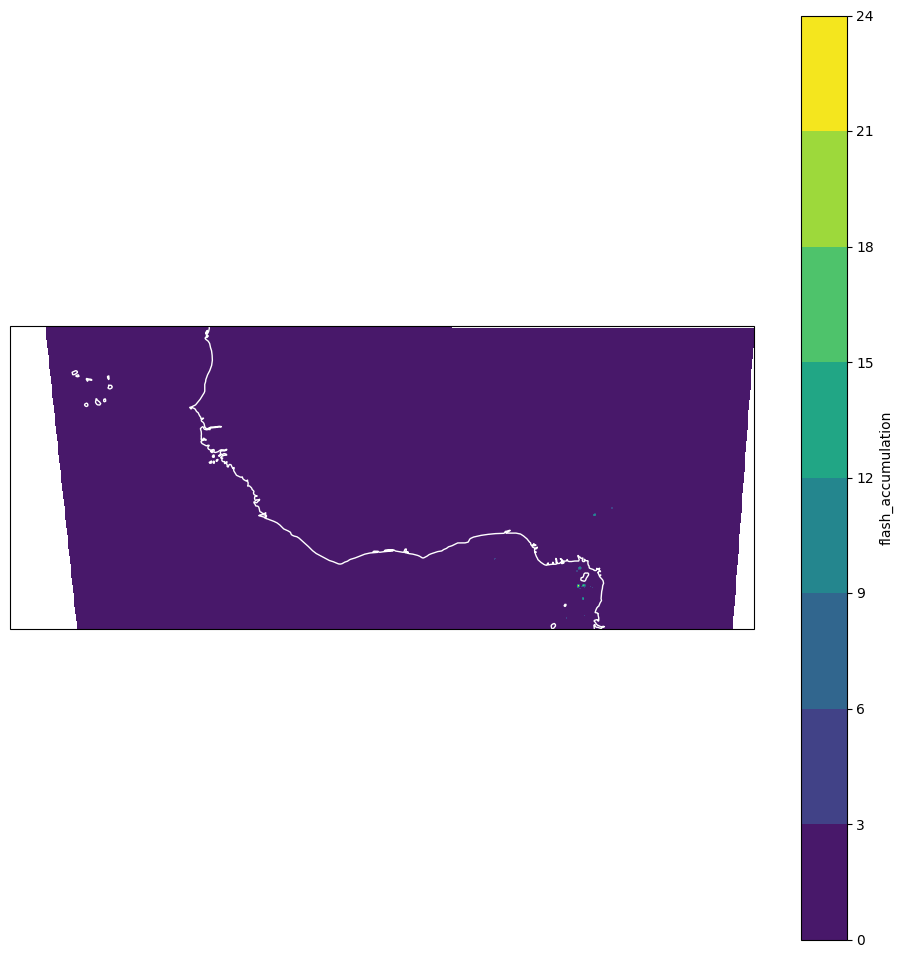

In [51]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
mtg_li_ds_clean['flash_accumulation'].plot.contourf(ax=ax1)
ax1.coastlines(color='w')

In [24]:
float(mtg_li_ds['latitude'].min()), float(mtg_li_ds['latitude'].max()), float(mtg_li_ds['longitude'].min()), float(mtg_li_ds['longitude'].max())

(0.027131086215376854,
 20.190547943115234,
 -27.115114212036133,
 19.97930908203125)

In [ ]:
[var1 for var1 in mtg_li_ds.variables]

In [ ]:
mtg_li_ds['latitude']


In [ ]:
48*30*65/1024


In [ ]:
fig1 = matplotlib.pyplot.figure(figsize=(12,12))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
mtg_li_ds['flash_accumulation'].plot.contourf(ax=ax1)
ax1.coastlines(color='w')


In [ ]:
iris.load('/gws/nopw/j04/ew4energy/TOOCAN-AFRICA-20240801-20240831.nc')